In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
df = pd.read_csv(
    r"C:\Users\deept\Downloads\archive\Sample - Superstore.csv",
    encoding="latin1"
)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 9994
Columns: 21


In [5]:
print("Column Names:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

Column Names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

First 5 Rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [6]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Missing Values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Duplicate Rows:
0


In [7]:
print("Data Types:")
print(df.dtypes)

Data Types:
Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object


In [8]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

print("Date columns converted successfully!")
print(df[["Order Date", "Ship Date"]].dtypes)

Date columns converted successfully!
Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object


In [9]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month Name"] = df["Order Date"].dt.strftime("%B")

print("New date columns created successfully!")
display(df[["Order Date", "Year", "Month", "Month Name"]].head())

New date columns created successfully!


,Order Date,Year,Month,Month Name
0,2016-11-08,2016,11,November
1,2016-11-08,2016,11,November
2,2016-06-12,2016,6,June
3,2015-10-11,2015,10,October
4,2015-10-11,2015,10,October


In [10]:
df["Month-Year"] = df["Order Date"].dt.to_period("M").astype(str)

print("Month-Year column created successfully!")
display(df[["Order Date", "Year", "Month", "Month Name", "Month-Year"]].head())

Month-Year column created successfully!


,Order Date,Year,Month,Month Name,Month-Year
0,2016-11-08,2016,11,November,2016-11
1,2016-11-08,2016,11,November,2016-11
2,2016-06-12,2016,6,June,2016-06
3,2015-10-11,2015,10,October,2015-10
4,2015-10-11,2015,10,October,2015-10


In [11]:
print("Categories:")
print(df["Category"].unique())

print("\nSub-Categories:")
print(df["Sub-Category"].unique())

print("\nRegions:")
print(df["Region"].unique())

print("\nSegments:")
print(df["Segment"].unique())

Categories:
<ArrowStringArray>
['Furniture', 'Office Supplies', 'Technology']
Length: 3, dtype: str

Sub-Categories:
<ArrowStringArray>
[  'Bookcases',      'Chairs',      'Labels',      'Tables',     'Storage',
 'Furnishings',         'Art',      'Phones',     'Binders',  'Appliances',
       'Paper', 'Accessories',   'Envelopes',   'Fasteners',    'Supplies',
    'Machines',     'Copiers']
Length: 17, dtype: str

Regions:
<ArrowStringArray>
['South', 'West', 'Central', 'East']
Length: 4, dtype: str

Segments:
<ArrowStringArray>
['Consumer', 'Corporate', 'Home Office']
Length: 3, dtype: str


In [12]:
# Save cleaned dataset
df.to_csv(
    r"C:\Users\deept\Downloads\Sales_Performance_Cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [13]:
# Calculate main sales KPIs

total_sales = df["Sales"].sum()
total_orders = df["Order ID"].nunique()
total_profit = df["Profit"].sum()
profit_margin = (total_profit / total_sales) * 100

print("SALES PERFORMANCE KPIs")
print("----------------------")
print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Profit Margin: {profit_margin:.2f}%")

SALES PERFORMANCE KPIs
----------------------
Total Sales: $2,297,200.86
Total Orders: 5,009
Total Profit: $286,397.02
Profit Margin: 12.47%


In [14]:
# Monthly Sales Trend

monthly_sales = (
    df.groupby("Month-Year")["Sales"]
    .sum()
    .reset_index()
)

print("Monthly Sales:")
display(monthly_sales)

Monthly Sales:


,Month-Year,Sales
0,2014-01,14236.8950
1,2014-02,4519.8920
2,2014-03,55691.0090
3,2014-04,28295.3450
4,2014-05,23648.2870
5,2014-06,34595.1276
6,2014-07,33946.3930
7,2014-08,27909.4685
8,2014-09,81777.3508
9,2014-10,31453.3930


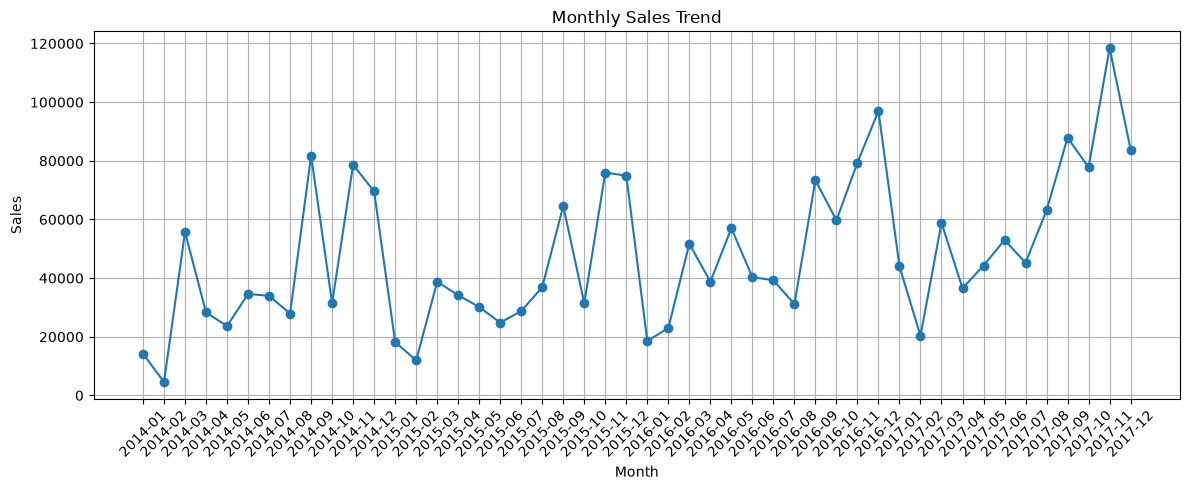

In [15]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales["Month-Year"],
    monthly_sales["Sales"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.show()

In [16]:
category_sales = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

print("Sales by Category:")
display(category_sales)

Sales by Category:


,Category,Sales
0,Technology,836154.0330
1,Furniture,741999.7953
2,Office Supplies,719047.0320


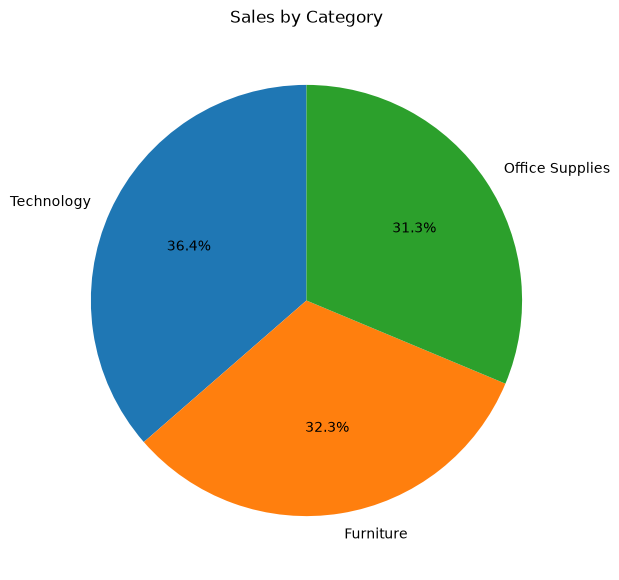

In [17]:
plt.figure(figsize=(7, 7))

plt.pie(
    category_sales["Sales"],
    labels=category_sales["Category"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Sales by Category")
plt.show()

In [18]:
region_sales = (
    df.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

print("Sales by Region:")
display(region_sales)

Sales by Region:


,Region,Sales
0,West,725457.8245
1,East,678781.2400
2,Central,501239.8908
3,South,391721.9050


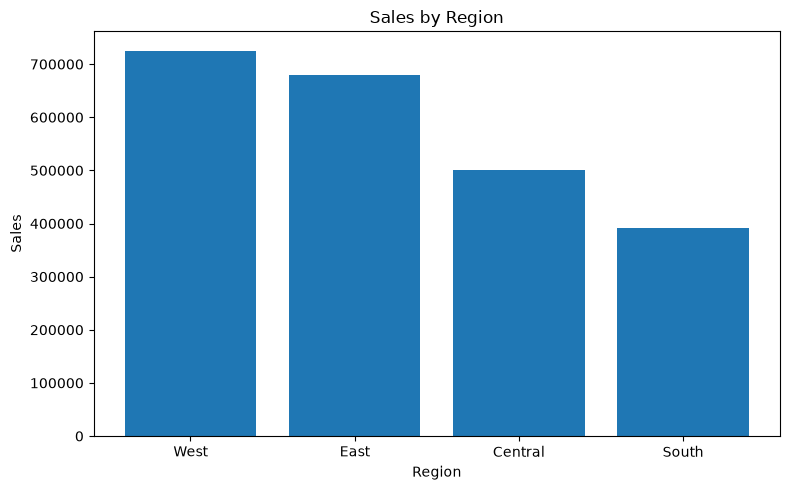

In [19]:
plt.figure(figsize=(8, 5))

plt.bar(
    region_sales["Region"],
    region_sales["Sales"]
)

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

In [20]:
top_products = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .reset_index()
)

print("Top 5 Products by Sales:")
display(top_products)

Top 5 Products by Sales:


,Product Name,Sales
0,Canon imageCLASS 2200 Advanced Copier,61599.824
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384
2,Cisco TelePresence System EX90 Videoconferenci...,22638.480
3,HON 5400 Series Task Chairs for Big and Tall,21870.576
4,GBC DocuBind TL300 Electric Binding System,19823.479


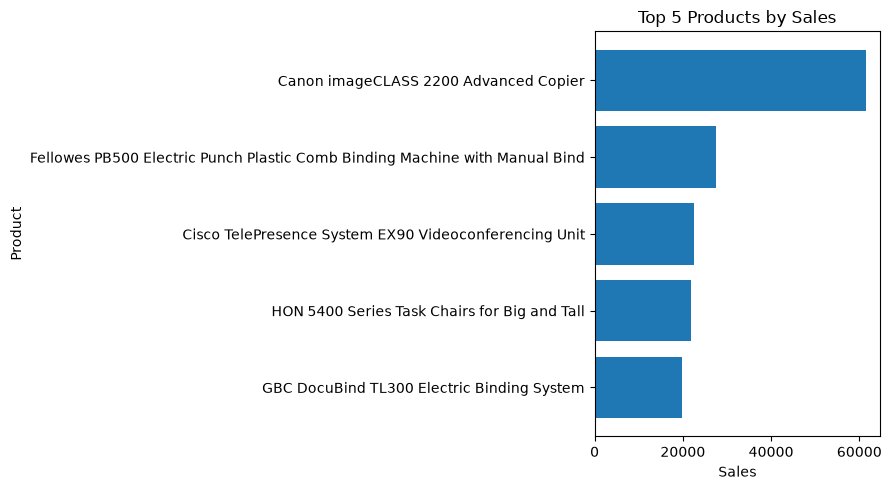

In [21]:
plt.figure(figsize=(9, 5))

plt.barh(
    top_products["Product Name"],
    top_products["Sales"]
)

plt.title("Top 5 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product")
plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()

In [22]:
profit_category = (
    df.groupby("Category")["Profit"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

print("Profit by Category:")
display(profit_category)

Profit by Category:


,Category,Profit
0,Technology,145454.9481
1,Office Supplies,122490.8008
2,Furniture,18451.2728


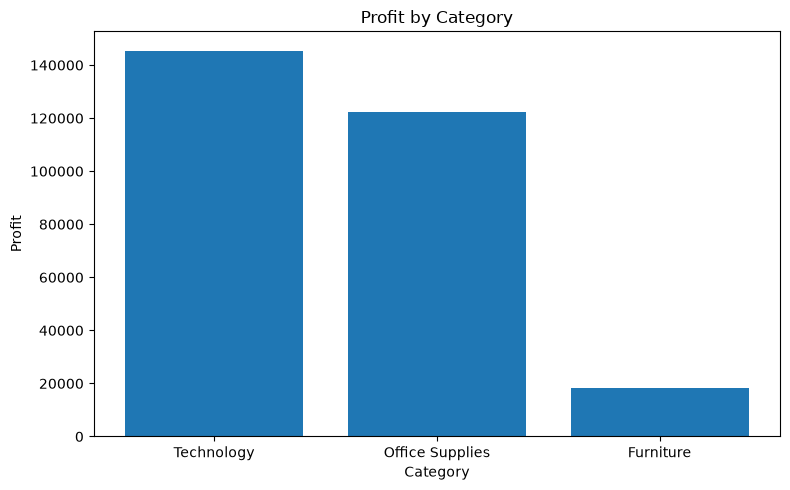

In [23]:
plt.figure(figsize=(8, 5))

plt.bar(
    profit_category["Category"],
    profit_category["Profit"]
)

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.tight_layout()

plt.show()

In [24]:
profit_region = (
    df.groupby("Region")["Profit"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

print("Profit by Region:")
display(profit_region)

Profit by Region:


,Region,Profit
0,West,108418.4489
1,East,91522.7800
2,South,46749.4303
3,Central,39706.3625


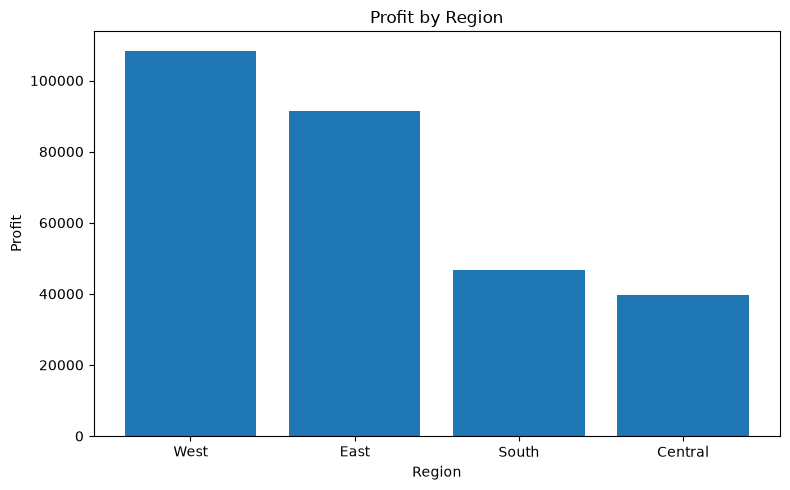

In [25]:
plt.figure(figsize=(8, 5))

plt.bar(
    profit_region["Region"],
    profit_region["Profit"]
)

plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")
plt.tight_layout()

plt.show()

In [26]:
segment_sales = (
    df.groupby("Segment")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

print("Sales by Segment:")
display(segment_sales)

Sales by Segment:


,Segment,Sales
0,Consumer,1.161401e+06
1,Corporate,7.061464e+05
2,Home Office,4.296531e+05


In [27]:
segment_profit = (
    df.groupby("Segment")["Profit"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

print("Profit by Segment:")
display(segment_profit)

Profit by Segment:


,Segment,Profit
0,Consumer,134119.2092
1,Corporate,91979.1340
2,Home Office,60298.6785


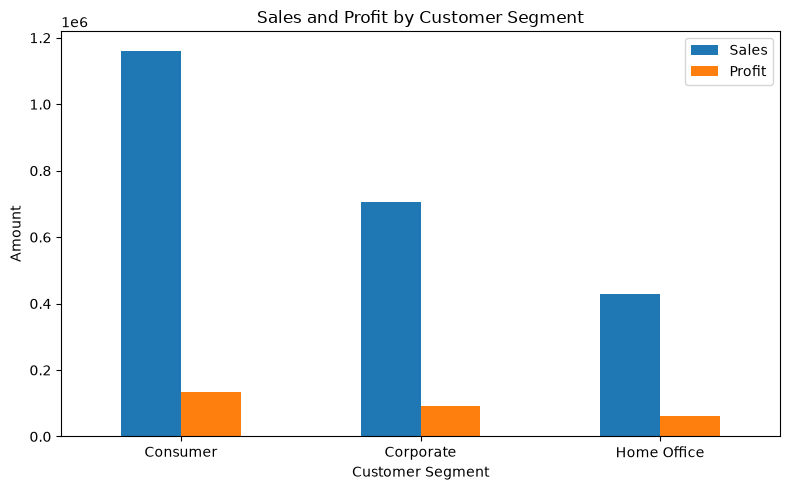

In [28]:
segment_analysis = df.groupby("Segment")[["Sales", "Profit"]].sum()

segment_analysis.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Sales and Profit by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

In [29]:
monthly_profit = (
    df.groupby(df["Order Date"].dt.to_period("M"))["Profit"]
    .sum()
    .reset_index()
)

monthly_profit["Order Date"] = monthly_profit["Order Date"].astype(str)

print("Monthly Profit:")
display(monthly_profit.head())

Monthly Profit:


,Order Date,Profit
0,2014-01,2450.1907
1,2014-02,862.3084
2,2014-03,498.7299
3,2014-04,3488.8352
4,2014-05,2738.7096


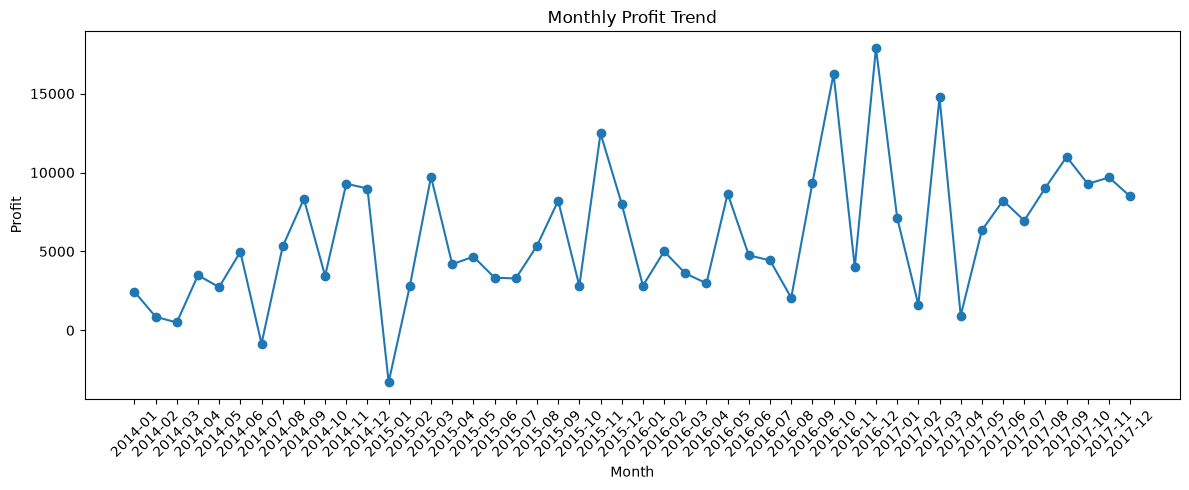

In [30]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_profit["Order Date"],
    monthly_profit["Profit"],
    marker="o"
)

plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Profit")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [31]:
top_products = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

print("Top 10 Products by Sales:")
display(top_products)

Top 10 Products by Sales:


,Product Name,Sales
0,Canon imageCLASS 2200 Advanced Copier,61599.824
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384
2,Cisco TelePresence System EX90 Videoconferenci...,22638.480
3,HON 5400 Series Task Chairs for Big and Tall,21870.576
4,GBC DocuBind TL300 Electric Binding System,19823.479
5,GBC Ibimaster 500 Manual ProClick Binding System,19024.500
6,Hewlett Packard LaserJet 3310 Copier,18839.686
7,HP Designjet T520 Inkjet Large Format Printer ...,18374.895
8,GBC DocuBind P400 Electric Binding System,17965.068
9,High Speed Automatic Electric Letter Opener,17030.312


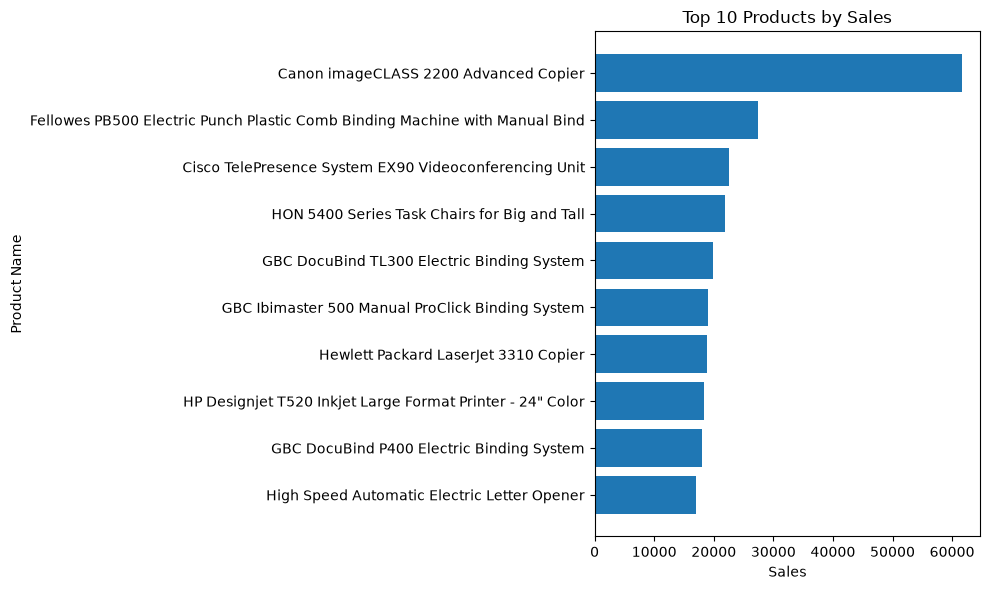

In [32]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_products["Product Name"],
    top_products["Sales"]
)

plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product Name")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [33]:
region_sales = (
    df.groupby("Region")["Sales"]
    .sum()
    .reset_index()
)

print("Sales by Region:")
display(region_sales)

Sales by Region:


,Region,Sales
0,Central,501239.8908
1,East,678781.2400
2,South,391721.9050
3,West,725457.8245


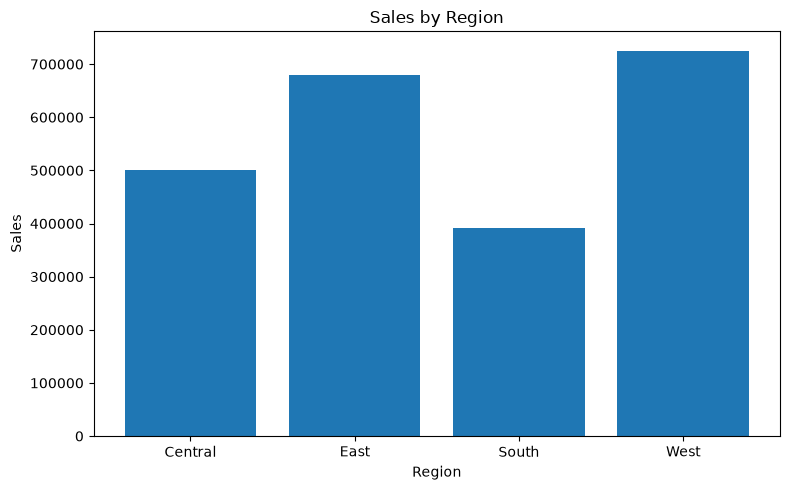

In [34]:
plt.figure(figsize=(8, 5))

plt.bar(
    region_sales["Region"],
    region_sales["Sales"]
)

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.tight_layout()
plt.show()

In [35]:
segment_sales = (
    df.groupby("Segment")["Sales"]
    .sum()
    .reset_index()
)

print("Sales by Segment:")
display(segment_sales)

Sales by Segment:


,Segment,Sales
0,Consumer,1.161401e+06
1,Corporate,7.061464e+05
2,Home Office,4.296531e+05


In [36]:
category_region = (
    df.groupby(["Region", "Category"])[["Sales", "Profit"]]
    .sum()
    .reset_index()
)

print("Category and Region Performance:")
display(category_region)

Category and Region Performance:


,Region,Category,Sales,Profit
0,Central,Furniture,163797.1638,-2871.0494
1,Central,Office Supplies,167026.4150,8879.9799
2,Central,Technology,170416.3120,33697.4320
3,East,Furniture,208291.2040,3046.1658
4,East,Office Supplies,205516.0550,41014.5791
5,East,Technology,264973.9810,47462.0351
6,South,Furniture,117298.6840,6771.2061
7,South,Office Supplies,125651.3130,19986.3928
8,South,Technology,148771.9080,19991.8314
9,West,Furniture,252612.7435,11504.9503


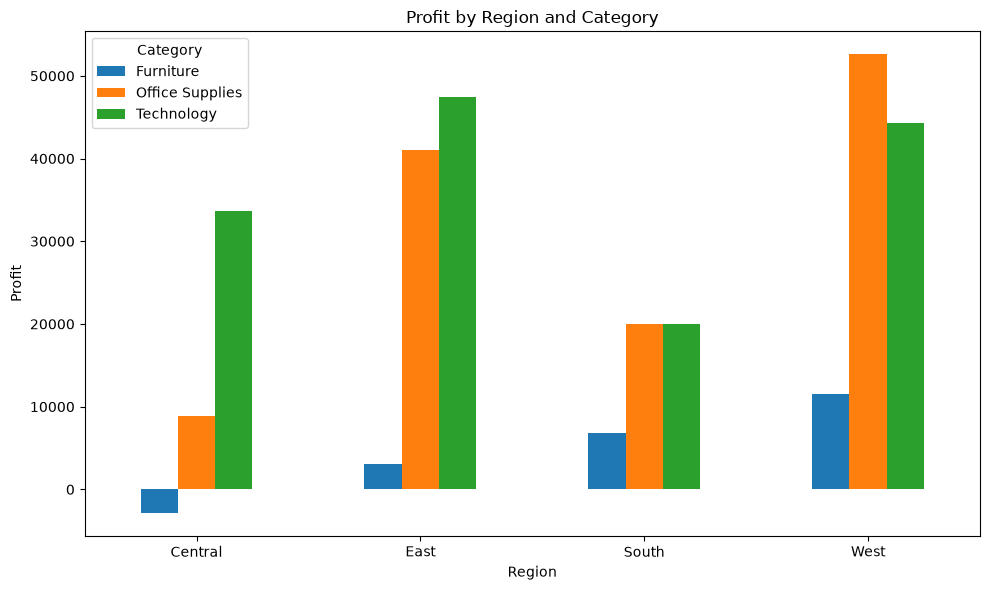

In [37]:
profit_region = category_region.pivot(
    index="Region",
    columns="Category",
    values="Profit"
)

profit_region.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Profit by Region and Category")
plt.xlabel("Region")
plt.ylabel("Profit")
plt.xticks(rotation=0)
plt.legend(title="Category")

plt.tight_layout()
plt.show()

In [38]:
category_sales = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print("Sales by Category:")
display(category_sales)

print("Best-Selling Category:", category_sales.idxmax())

Sales by Category:


Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

Best-Selling Category: Technology


In [39]:
category_profit = (
    df.groupby("Category")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

print("Profit by Category:")
display(category_profit)

print("Most Profitable Category:", category_profit.idxmax())

Profit by Category:


Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64

Most Profitable Category: Technology


In [40]:
top_profit_products = (
    df.groupby("Product Name")["Profit"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

print("Top 10 Most Profitable Products:")
display(top_profit_products)

Top 10 Most Profitable Products:


,Product Name,Profit
0,Canon imageCLASS 2200 Advanced Copier,25199.9280
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,7753.0390
2,Hewlett Packard LaserJet 3310 Copier,6983.8836
3,Canon PC1060 Personal Laser Copier,4570.9347
4,HP Designjet T520 Inkjet Large Format Printer ...,4094.9766
5,Ativa V4110MDD Micro-Cut Shredder,3772.9461
6,"3D Systems Cube Printer, 2nd Generation, Magenta",3717.9714
7,Plantronics Savi W720 Multi-Device Wireless He...,3696.2820
8,Ibico EPK-21 Electric Binding System,3345.2823
9,Zebra ZM400 Thermal Label Printer,3343.5360


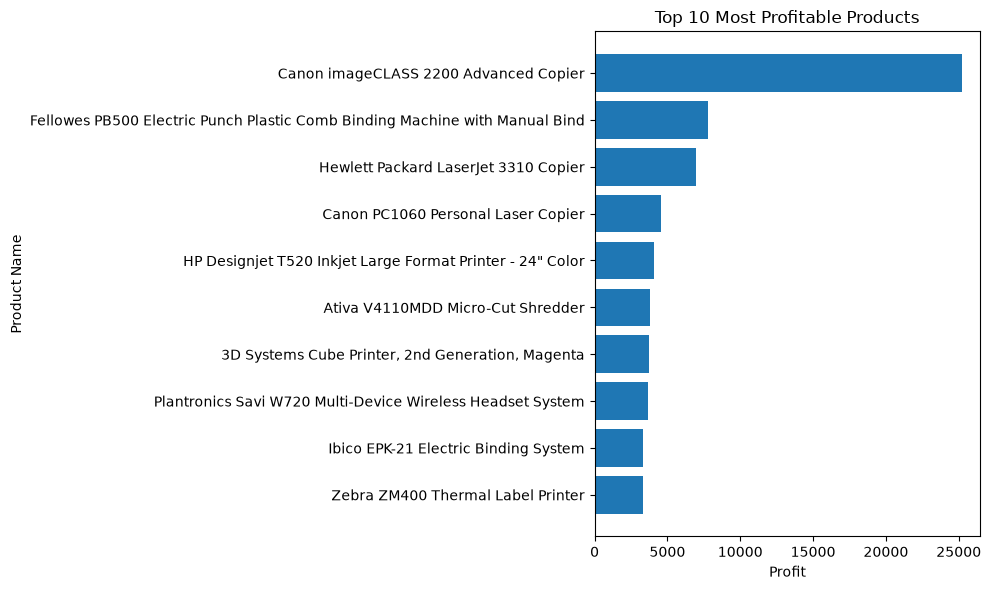

In [41]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_profit_products["Product Name"],
    top_profit_products["Profit"]
)

plt.title("Top 10 Most Profitable Products")
plt.xlabel("Profit")
plt.ylabel("Product Name")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [42]:
discount_profit = (
    df.groupby("Discount")["Profit"]
    .mean()
    .reset_index()
)

print("Average Profit by Discount:")
display(discount_profit)

Average Profit by Discount:


,Discount,Profit
0,0.00,66.900292
1,0.10,96.055074
2,0.15,27.288298
3,0.20,24.702572
4,0.30,-45.679636
5,0.32,-88.560656
6,0.40,-111.927429
7,0.45,-226.646464
8,0.50,-310.703456
9,0.60,-43.077212


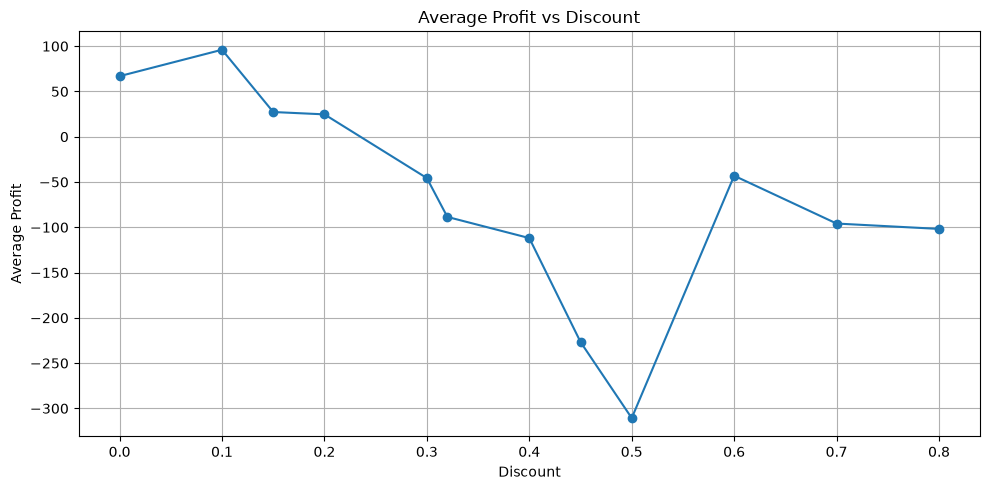

In [44]:
plt.figure(figsize=(10, 5))

plt.plot(
    discount_profit["Discount"],
    discount_profit["Profit"],
    marker="o"
)

plt.title("Average Profit vs Discount")
plt.xlabel("Discount")
plt.ylabel("Average Profit")
plt.grid(True)

plt.tight_layout()
plt.show()

In [45]:
# Final KPI Summary

kpi_summary = {
    "Total Sales": df["Sales"].sum(),
    "Total Profit": df["Profit"].sum(),
    "Total Orders": df["Order ID"].nunique(),
    "Total Quantity": df["Quantity"].sum(),
    "Average Order Value": df["Sales"].sum() / df["Order ID"].nunique(),
    "Profit Margin (%)": (df["Profit"].sum() / df["Sales"].sum()) * 100
}

print("FINAL SALES PERFORMANCE KPI SUMMARY")
print("-----------------------------------")

for key, value in kpi_summary.items():
    if "Margin" in key:
        print(f"{key}: {value:.2f}%")
    elif "Orders" in key or "Quantity" in key:
        print(f"{key}: {value:,.0f}")
    else:
        print(f"{key}: ${value:,.2f}")

FINAL SALES PERFORMANCE KPI SUMMARY
-----------------------------------
Total Sales: $2,297,200.86
Total Profit: $286,397.02
Total Orders: 5,009
Total Quantity: 37,873
Average Order Value: $458.61
Profit Margin (%): 12.47%


In [46]:
print("FINAL DATA VALIDATION")
print("---------------------")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nDate range:")
print(df["Order Date"].min(), "to", df["Order Date"].max())

FINAL DATA VALIDATION
---------------------
Rows: 9994
Columns: 25

Missing values:
0

Duplicate rows:
0

Date range:
2014-01-03 00:00:00 to 2017-12-30 00:00:00


In [47]:
print("BUSINESS INSIGHTS")
print("=================")

# 1. Best-selling category
best_category = df.groupby("Category")["Sales"].sum().idxmax()

# 2. Most profitable category
best_profit_category = df.groupby("Category")["Profit"].sum().idxmax()

# 3. Best-performing region by sales
best_region = df.groupby("Region")["Sales"].sum().idxmax()

# 4. Most profitable region
best_profit_region = df.groupby("Region")["Profit"].sum().idxmax()

# 5. Best customer segment
best_segment = df.groupby("Segment")["Sales"].sum().idxmax()

# 6. Top-selling product
best_product = df.groupby("Product Name")["Sales"].sum().idxmax()

# 7. Most profitable product
best_profit_product = df.groupby("Product Name")["Profit"].sum().idxmax()

print(f"1. The highest-selling category is {best_category}.")
print(f"2. The most profitable category is {best_profit_category}.")
print(f"3. The region with the highest sales is {best_region}.")
print(f"4. The most profitable region is {best_profit_region}.")
print(f"5. The customer segment generating the highest sales is {best_segment}.")
print(f"6. The top-selling product is {best_product}.")
print(f"7. The most profitable product is {best_profit_product}.")

BUSINESS INSIGHTS
1. The highest-selling category is Technology.
2. The most profitable category is Technology.
3. The region with the highest sales is West.
4. The most profitable region is West.
5. The customer segment generating the highest sales is Consumer.
6. The top-selling product is Canon imageCLASS 2200 Advanced Copier.
7. The most profitable product is Canon imageCLASS 2200 Advanced Copier.


In [48]:
print("BUSINESS RECOMMENDATIONS")
print("=======================")

print("1. Focus on Technology products because they generate the highest sales and profit.")
print("2. Strengthen sales and marketing activities in the West region.")
print("3. Continue targeting the Consumer segment because it generates the highest sales.")
print("4. Promote high-performing products such as the Canon imageCLASS 2200 Advanced Copier.")
print("5. Monitor discounts carefully to maintain profitability while increasing sales.")
print("6. Analyze low-profit products and regions to identify areas for improvement.")

BUSINESS RECOMMENDATIONS
1. Focus on Technology products because they generate the highest sales and profit.
2. Strengthen sales and marketing activities in the West region.
3. Continue targeting the Consumer segment because it generates the highest sales.
4. Promote high-performing products such as the Canon imageCLASS 2200 Advanced Copier.
5. Monitor discounts carefully to maintain profitability while increasing sales.
6. Analyze low-profit products and regions to identify areas for improvement.


In [49]:
# Save the cleaned dataset
df.to_csv("Sales_Performance_Cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
